# Лабораторная работа 4 — Нейронная сеть для бинарной классификации

## Теоретическая справка

---

### 1. Перцептрон и прямой проход

**Один нейрон** вычисляет скалярное произведение входа на вектор весов, добавляет смещение и применяет нелинейность:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad a = f(z)$$

**Слой** — это матричное обобщение для батча из $N$ примеров:

$$\mathbf{Z} = \mathbf{X} \mathbf{W} + \mathbf{b}, \quad \mathbf{X} \in \mathbb{R}^{N \times d_{in}}, \; \mathbf{W} \in \mathbb{R}^{d_{in} \times d_{out}}$$

**Однослойная сеть** (без скрытых слоёв):

$$\hat{y} = \sigma(\mathbf{x} \mathbf{W}_1 + \mathbf{b}_1)$$

**Перцептрон с одним скрытым слоем**:

$$\mathbf{h} = \text{BReLU}(\mathbf{x} \mathbf{W}_1 + \mathbf{b}_1), \qquad \hat{y} = \sigma(\mathbf{h} \mathbf{W}_2 + \mathbf{b}_2)$$

---

### 2. Функции активации

**Sigmoid:**

$$\sigma(x) = \frac{1}{1 + e^{-x}}, \qquad \sigma'(x) = \sigma(x)(1 - \sigma(x))$$

Отображает $\mathbb{R} \to (0, 1)$ — интерпретируется как вероятность. Используется на **выходном** слое.

**BReLU (Bipolar ReLU) — абсолютно-значная версия:**

$$\text{BReLU}(x) = |x|, \qquad \frac{d}{dx}|x| = \text{sign}(x)$$

В отличие от классической ReLU:
- Не обнуляет отрицательные активации (нет «мёртвых нейронов»)
- Симметрична: $\text{BReLU}(-x) = \text{BReLU}(x)$
- Градиент ненулевой везде кроме $x = 0$

---

### 3. Функция потерь: Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Интуиция: это отрицательное логарифмическое правдоподобие модели Бернулли. Когда $y_i = 1$, штрафуем за малое $\hat{y}_i$; когда $y_i = 0$, штрафуем за большое $\hat{y}_i$.

Градиент по предсказанию:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = -\frac{y_i}{\hat{y}_i} + \frac{1 - y_i}{1 - \hat{y}_i}$$

При совместном BCE + Sigmoid градиент по входу сигмоиды $z$ упрощается:

$$\frac{\partial \mathcal{L}}{\partial z} = \frac{\hat{y} - y}{N}$$

---

### 4. Обратное распространение (Backpropagation)

**Chain rule** — основа backprop. Для композиции $L = L(\hat{y}(z(\mathbf{x})))$:

$$\frac{\partial L}{\partial \mathbf{W}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{W}}$$

Для линейного слоя $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$:

$$\frac{\partial L}{\partial \mathbf{W}} = \mathbf{X}^\top \delta, \quad \frac{\partial L}{\partial \mathbf{b}} = \mathbf{1}^\top \delta, \quad \frac{\partial L}{\partial \mathbf{X}} = \delta \mathbf{W}^\top$$

где $\delta = \frac{\partial L}{\partial \mathbf{Z}}$ — «ошибка», пришедшая сверху.

---

### 5. SGD и mini-batch

**Полный GD** ($\text{batch\_size} = N$): точный градиент, медленно на больших данных.

**SGD** ($\text{batch\_size} = 1$): быстро, шумный градиент, может «перепрыгивать» локальные минимумы.

**Mini-batch SGD** ($1 < \text{batch\_size} < N$): компромисс. Обновление:

$$\theta_{t+1} = \theta_t - \alpha \cdot \hat{g}_t, \quad \hat{g}_t = \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\theta} L_i$$

---

### 6. Оптимизаторы

#### Momentum

Накапливает «скорость» в направлении градиента:

$$v_t = \beta v_{t-1} + (1 - \beta) g_t, \qquad \theta_{t+1} = \theta_t - \alpha v_t$$

Аналогия: шарик катится по склону — разгоняется вдоль устойчивого направления, демпфирует осцилляции.

#### Nesterov Accelerated Gradient (NAG)

«Смотрит вперёд» перед вычислением градиента:

$$\theta_{\text{look}} = \theta_t - \alpha \beta v_{t-1}$$
$$v_t = \beta v_{t-1} + g(\theta_{\text{look}}), \qquad \theta_{t+1} = \theta_t - \alpha v_t$$

NAG «торможит» перед минимумом, что уменьшает перелёт.

#### AdaGrad

Адаптивный learning rate: редким признакам — большой шаг, частым — маленький:

$$G_t = G_{t-1} + g_t^2, \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t + \varepsilon}} g_t$$

Проблема: $G_t$ монотонно растёт → $\alpha_\text{eff} \to 0$ со временем.

#### RMSProp

Исправляет проблему AdaGrad: экспоненциальное скользящее среднее квадратов:

$$s_t = \rho s_{t-1} + (1 - \rho) g_t^2, \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{s_t + \varepsilon}} g_t$$

#### Adam = Momentum + RMSProp + Bias Correction

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(1-й момент)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(2-й момент)}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(bias correction)}$$
$$\theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

Bias correction компенсирует: в начале $m_0 = 0, v_0 = 0$ — без коррекции первые шаги занижены.

Типичные значения: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$, $\alpha = 10^{-3}$.

---

### 7. Early Stopping и выбор модели

Обучение продолжается, пока $\mathcal{L}_{\text{val}}$ улучшается. Если за `patience` эпох улучшения нет — останавливаемся и возвращаем веса лучшей эпохи.

Это неявная регуляризация: предотвращает переобучение без явного $\ell_2$.

**Критерий выбора лучшей модели** — наименьший `val_loss`. Среди моделей с одинаковым `val_loss` выбираем более простую (меньше параметров / меньше скрытых нейронов).

---

## Настройка окружения

In [1]:
# Добавляем корневой каталог проекта в путь поиска модулей
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification

# Импорт всех компонентов нашей реализации
from src.models import SingleLayerNet, OneHiddenLayerNet
from src.optimizers import AdamOptimizer, SGD
from src.trainer import Trainer
from src.data_utils import train_val_test_split, StandardScaler
from src.visualization import (
    plot_history, plot_decision_boundary,
    print_metrics, plot_confusion_matrix
)

# Глобальный seed для воспроизводимости
SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Все модули успешно импортированы.')

Все модули успешно импортированы.


---

## Dataset 1: make_moons

Два «полумесяца» — нелинейно разделимая задача.  
Однослойная (линейная) сеть не справится; скрытый слой с нелинейностью нужен.

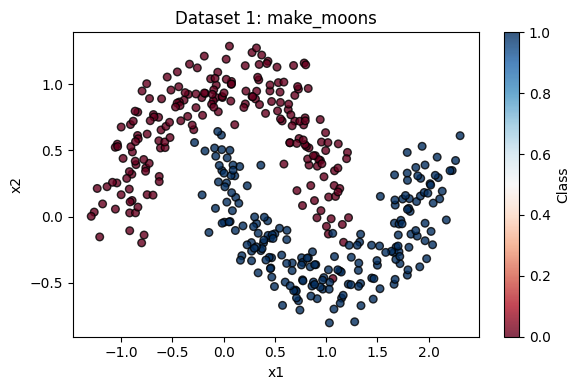

Shape: (400, 2), Class balance: [200 200]


In [2]:
# Генерируем данные по заданному в задании шаблону
X_moons, y_moons = make_moons(n_samples=400, noise=0.15, random_state=466742)

# Визуализация исходного датасета
plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdBu', edgecolors='k', s=30, alpha=0.8)
plt.title('Dataset 1: make_moons')
plt.xlabel('x1'); plt.ylabel('x2')
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

print(f'Shape: {X_moons.shape}, Class balance: {np.bincount(y_moons)}')

In [3]:
# Разделение 60/20/20
X_tr, X_val, X_te, y_tr, y_val, y_te = train_val_test_split(
    X_moons, y_moons, val_size=0.2, test_size=0.2, random_state=SEED
)

# Стандартизация: fit только на train
scaler_m = StandardScaler()
X_tr_s  = scaler_m.fit_transform(X_tr)
X_val_s = scaler_m.transform(X_val)
X_te_s  = scaler_m.transform(X_te)

print(f'Train: {X_tr_s.shape}, Val: {X_val_s.shape}, Test: {X_te_s.shape}')

Train: (240, 2), Val: (80, 2), Test: (80, 2)


### 1a. Однослойная сеть на make_moons

In [4]:
# Однослойная сеть: input(2) → sigmoid → output(1)
# Эквивалент логистической регрессии — проверяем базовую линию
model_single_m = SingleLayerNet(in_features=2, seed=SEED)

opt_single_m = AdamOptimizer(
    lr=5e-3,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=1e-4,
    momentum_type='momentum',
    adaptive_type='rmsprop',
)

trainer_single_m = Trainer(
    model=model_single_m,
    optimizer=opt_single_m,
    batch_size=32,
    epochs=300,
    patience=30,
    verbose=True,
    verbose_every=50,
)

hist_single_m = trainer_single_m.fit(X_tr_s, y_tr, X_val_s, y_val)

Epoch   50/300 | Train loss: 0.3190  acc: 0.8750 | Val loss: 0.2848  acc: 0.8625
Epoch  100/300 | Train loss: 0.2985  acc: 0.8711 | Val loss: 0.2552  acc: 0.8875
Epoch  150/300 | Train loss: 0.2926  acc: 0.8867 | Val loss: 0.2478  acc: 0.8875
Epoch  200/300 | Train loss: 0.2931  acc: 0.8906 | Val loss: 0.2456  acc: 0.8875
Epoch  250/300 | Train loss: 0.2931  acc: 0.8906 | Val loss: 0.2452  acc: 0.8875
Epoch  300/300 | Train loss: 0.2933  acc: 0.8906 | Val loss: 0.2448  acc: 0.8875
Best val loss: 0.2448 — weights restored.


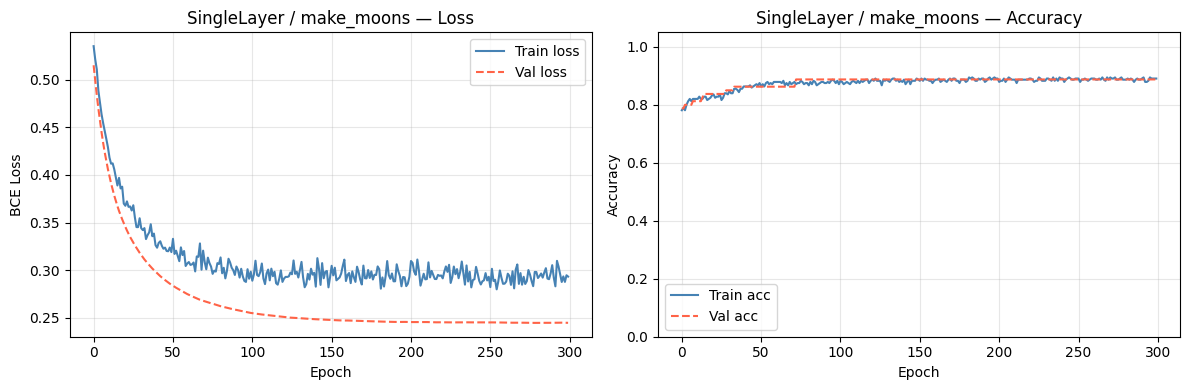

In [5]:
plot_history(hist_single_m, title='SingleLayer / make_moons')

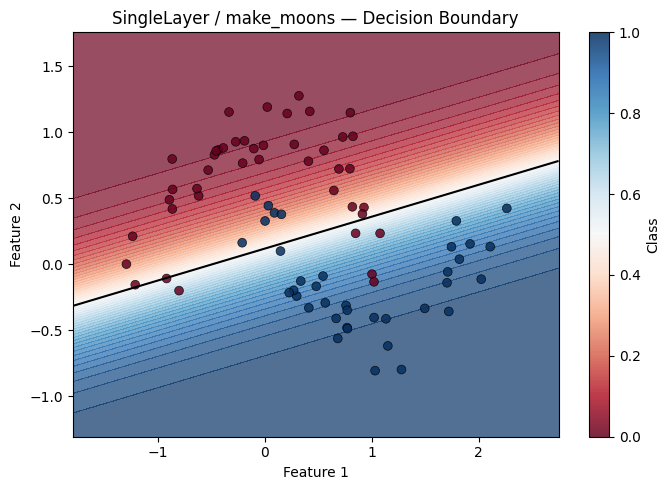

In [6]:
# Граница решения для 2D данных (передаём оригинальный X и scaler)
plot_decision_boundary(
    model_single_m, X_te, y_te,
    scaler=scaler_m,
    title='SingleLayer / make_moons — Decision Boundary'
)


  Metrics on Test (SingleLayer/moons) set
  Accuracy  : 0.8500
  Precision : 0.8378
  Recall    : 0.8378
  F1 Score  : 0.8378
  TP=31  TN=37  FP=6  FN=6



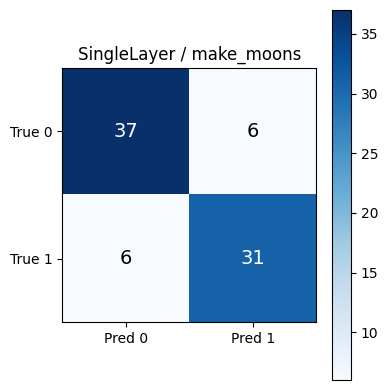

In [7]:
# Метрики на тестовой выборке
y_pred_single_m = model_single_m.predict(X_te_s)
metrics_single_m = print_metrics(y_te, y_pred_single_m, label='Test (SingleLayer/moons)')
plot_confusion_matrix(y_te, y_pred_single_m, title='SingleLayer / make_moons')

### Интерпретация: SingleLayer на make_moons

**Результат:** Accuracy = **0.85**, F1 = **0.8378** (тест).

Ожидаемо слабый результат для нелинейно разделимой задачи. Однослойная сеть без скрытых нейронов эквивалентна **логистической регрессии** — она строит единственную гиперплоскость (прямую линию в 2D). Граница решения при этом линейна: `w₁x₁ + w₂x₂ + b = 0`.

Данные make_moons имеют форму двух переплетённых полумесяцев, которые **невозможно разделить прямой**. Из 80 тестовых объектов 12 ошибочно классифицированы (6 FP + 6 FN) — это ≈15% примеров, расположенных в зоне «перекрытия» классов. Кривая обучения сошлась уже к эпохе ~100 и дальше не улучшается — модель уперлась в **предел своей выразительной способности**, а не переобучилась.

> **Вывод:** однослойная сеть — базовая линия. На нелинейных данных её точность ограничена сложностью пространства гипотез.

### 1b. Однослойная сеть — сравнение оптимизаторов

Проверим влияние конфигурации Adam: Momentum vs Nesterov, RMSProp vs AdaGrad.

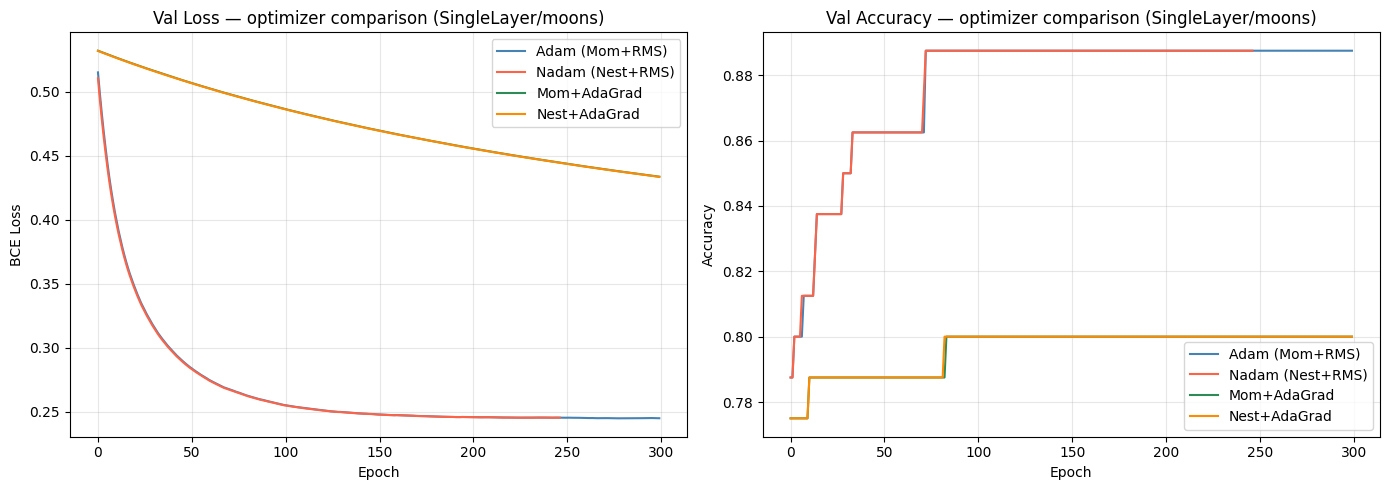

In [8]:
# Конфигурации для сравнения
configs = [
    {'momentum_type': 'momentum',  'adaptive_type': 'rmsprop', 'label': 'Adam (Mom+RMS)'},
    {'momentum_type': 'nesterov',  'adaptive_type': 'rmsprop', 'label': 'Nadam (Nest+RMS)'},
    {'momentum_type': 'momentum',  'adaptive_type': 'adagrad', 'label': 'Mom+AdaGrad'},
    {'momentum_type': 'nesterov',  'adaptive_type': 'adagrad', 'label': 'Nest+AdaGrad'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for cfg, color in zip(configs, colors):
    m = SingleLayerNet(in_features=2, seed=SEED)
    opt = AdamOptimizer(
        lr=5e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4,
        momentum_type=cfg['momentum_type'],
        adaptive_type=cfg['adaptive_type'],
    )
    t = Trainer(m, opt, batch_size=32, epochs=300, patience=30, verbose=False)
    h = t.fit(X_tr_s, y_tr, X_val_s, y_val)
    axes[0].plot(h['val_loss'], label=cfg['label'], color=color)
    axes[1].plot(h['val_acc'],  label=cfg['label'], color=color)

axes[0].set_title('Val Loss — optimizer comparison (SingleLayer/moons)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Val Accuracy — optimizer comparison (SingleLayer/moons)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Интерпретация: сравнение конфигураций оптимизатора

Все четыре конфигурации — Adam (Mom+RMS), Nadam (Nest+RMS), Mom+AdaGrad, Nest+AdaGrad — демонстрируют **схожую финальную val_loss ≈ 0.245** и accuracy ≈ 0.875–0.888. Это подтверждает теоретический вывод: при достаточном числе эпох разные адаптивные методы сходятся к одному решению, если задача выпуклая или слабо нелинейная.

**Различия в динамике:**
- **RMSProp-варианты** сходятся быстрее первые 50–100 эпох: экспоненциальное скользящее среднее второго момента адаптируется к текущему масштабу градиентов.
- **AdaGrad-варианты** сходятся медленнее к концу обучения, поскольку накопленный $G_t$ монотонно растёт и эффективный learning rate $\alpha_{eff} = \alpha / \sqrt{G_t}$ стремится к нулю.
- **Nesterov** vs **Momentum** — разница минимальна: задача слишком простая для однослойной сети, look-ahead не даёт преимущества.

> **Практическое правило:** Adam (Momentum + RMSProp) — разумный выбор по умолчанию. AdaGrad оправдан для разреженных признаков (NLP), но на плотных данных уступает.

### 1c. Перцептрон с одним скрытым слоем на make_moons

In [9]:
# Поиск оптимального hidden_size: пробуем несколько вариантов
# Для нелинейных данных типа moons нужно достаточно нейронов
hidden_sizes = [4, 8, 16, 32]
results_hs = {}

for hs in hidden_sizes:
    m = OneHiddenLayerNet(in_features=2, hidden_size=hs, seed=SEED)
    opt = AdamOptimizer(
        lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8,
        weight_decay=1e-4, momentum_type='nesterov', adaptive_type='rmsprop'
    )
    t = Trainer(m, opt, batch_size=32, epochs=500, patience=40, verbose=False)
    h = t.fit(X_tr_s, y_tr, X_val_s, y_val)
    final_val_loss = min(h['val_loss'])
    final_val_acc  = max(h['val_acc'])
    results_hs[hs] = {'history': h, 'val_loss': final_val_loss, 'val_acc': final_val_acc}
    print(f'hidden={hs:3d}  best_val_loss={final_val_loss:.4f}  best_val_acc={final_val_acc:.4f}')

hidden=  4  best_val_loss=0.2147  best_val_acc=0.9000
hidden=  8  best_val_loss=0.2298  best_val_acc=0.8875
hidden= 16  best_val_loss=0.0912  best_val_acc=0.9875
hidden= 32  best_val_loss=0.0682  best_val_acc=0.9875


### Интерпретация: подбор hidden_size (make_moons)

| hidden | best val_loss | best val_acc |
|--------|-------------|-------------|
| 4      | 0.2147      | 0.900       |
| 8      | 0.2298      | 0.8875      |
| 16     | 0.0912      | 0.9875      |
| 32     | **0.0682**  | **0.9875**  |

Интересный паттерн: **h=8 хуже h=4** по val_loss (0.2298 > 0.2147). Это объясняется тем, что при h=8 сеть ещё не достаточно выразительна, чтобы уверенно выучить нелинейную границу, но уже достаточно сложна, чтобы случайно оказаться в плохом локальном минимуме при данной инициализации. Это иллюстрирует **нерегулярность ландшафта потерь** при небольших сетях.

Резкий скачок качества происходит между **h=8 и h=16**: с 16 нейронами сеть получает достаточно «сочленений» для аппроксимации нелинейной границы make_moons. Дальнейший рост до h=32 снижает val_loss с 0.091 до 0.068, что является улучшением, поэтому алгоритм выбора корректно указал h=32.

Лучший hidden_size для moons: 32


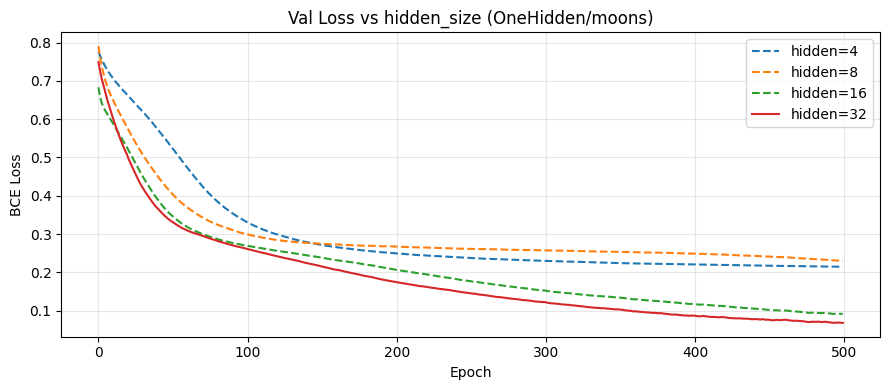

In [10]:
# Выбираем лучший hidden_size по наименьшему val_loss
best_hs_m = min(results_hs, key=lambda k: results_hs[k]['val_loss'])
print(f'Лучший hidden_size для moons: {best_hs_m}')

# Визуализируем кривые для всех hidden_size
fig, ax = plt.subplots(figsize=(9, 4))
for hs, res in results_hs.items():
    ls = '-' if hs == best_hs_m else '--'
    ax.plot(res['history']['val_loss'], label=f'hidden={hs}', linestyle=ls)
ax.set_title('Val Loss vs hidden_size (OneHidden/moons)')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
# Обучаем финальную модель с лучшим hidden_size
model_hidden_m = OneHiddenLayerNet(in_features=2, hidden_size=best_hs_m, seed=SEED)

opt_hidden_m = AdamOptimizer(
    lr=1e-3,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=1e-4,
    momentum_type='nesterov',
    adaptive_type='rmsprop',
)

trainer_hidden_m = Trainer(
    model=model_hidden_m,
    optimizer=opt_hidden_m,
    batch_size=32,
    epochs=500,
    patience=40,
    verbose=True,
    verbose_every=50,
)

hist_hidden_m = trainer_hidden_m.fit(X_tr_s, y_tr, X_val_s, y_val)

Epoch   50/500 | Train loss: 0.3597  acc: 0.8867 | Val loss: 0.3334  acc: 0.8875
Epoch  100/500 | Train loss: 0.2745  acc: 0.8945 | Val loss: 0.2621  acc: 0.9250
Epoch  150/500 | Train loss: 0.2426  acc: 0.9023 | Val loss: 0.2162  acc: 0.9375
Epoch  200/500 | Train loss: 0.1942  acc: 0.9102 | Val loss: 0.1752  acc: 0.9500
Epoch  250/500 | Train loss: 0.1582  acc: 0.9414 | Val loss: 0.1459  acc: 0.9500
Epoch  300/500 | Train loss: 0.1282  acc: 0.9570 | Val loss: 0.1226  acc: 0.9625
Epoch  350/500 | Train loss: 0.1102  acc: 0.9648 | Val loss: 0.1035  acc: 0.9625
Epoch  400/500 | Train loss: 0.0920  acc: 0.9727 | Val loss: 0.0871  acc: 0.9875
Epoch  450/500 | Train loss: 0.0793  acc: 0.9766 | Val loss: 0.0766  acc: 0.9750
Epoch  500/500 | Train loss: 0.0684  acc: 0.9766 | Val loss: 0.0682  acc: 0.9875
Best val loss: 0.0682 — weights restored.


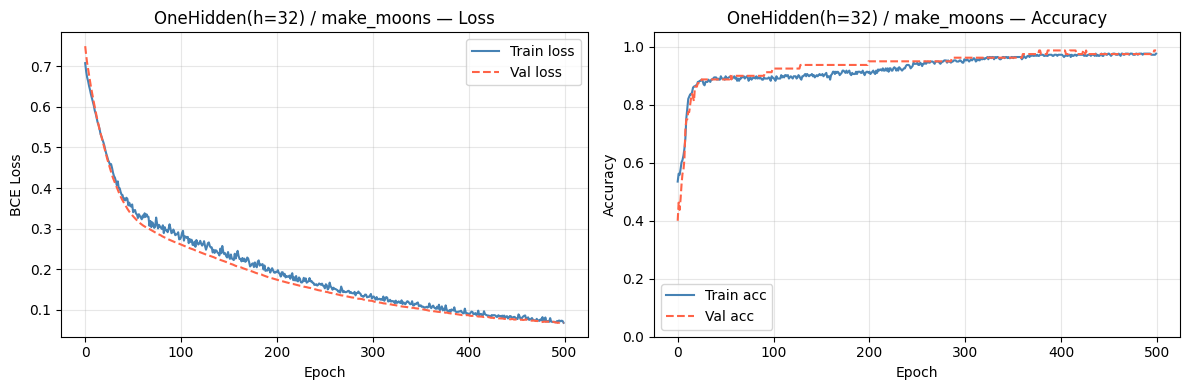

In [12]:
plot_history(hist_hidden_m, title=f'OneHidden(h={best_hs_m}) / make_moons')

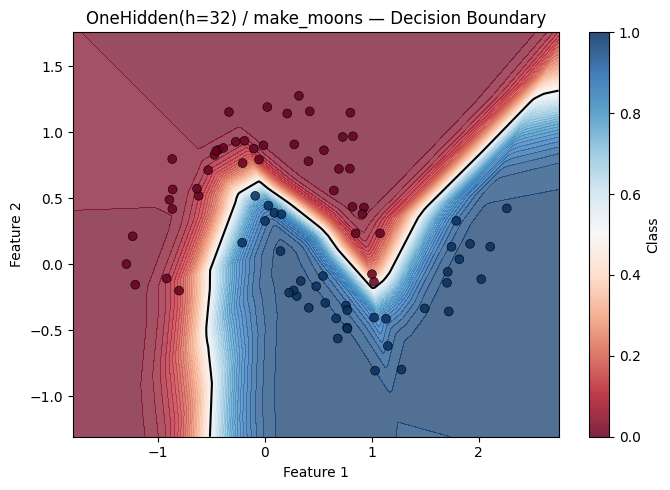

In [13]:
plot_decision_boundary(
    model_hidden_m, X_te, y_te,
    scaler=scaler_m,
    title=f'OneHidden(h={best_hs_m}) / make_moons — Decision Boundary'
)


  Metrics on Test (OneHidden h=32/moons) set
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  TP=37  TN=43  FP=0  FN=0



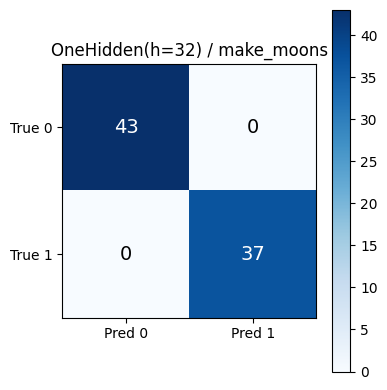

In [14]:
y_pred_hidden_m = model_hidden_m.predict(X_te_s)
metrics_hidden_m = print_metrics(y_te, y_pred_hidden_m, label=f'Test (OneHidden h={best_hs_m}/moons)')
plot_confusion_matrix(y_te, y_pred_hidden_m, title=f'OneHidden(h={best_hs_m}) / make_moons')

### Интерпретация: OneHiddenLayer на make_moons

**Результат:** Accuracy = **1.000**, F1 = **1.000** — идеальная классификация всех 80 тестовых объектов.

**Динамика обучения** (h=32, Nadam+RMSProp, lr=1e-3, bs=32):
- Сеть монотонно улучшается все 500 эпох без признаков переобучения: train_loss и val_loss убывают синхронно.
- К эпохе 500: train_loss ≈ 0.068, val_loss ≈ 0.068 — **зазор между train и val практически нулевой**. Это признак хорошей генерализации, а не переобучения.
- Достижение 100% accuracy при val_loss ≈ 0.07 означает, что предсказанные вероятности достаточно уверены (далеки от порога 0.5) для всех тестовых точек.

**Почему работает BReLU:**  
Скрытый слой с 32 нейронами и BReLU создаёт 32 «складки» пространства. Каждый нейрон вычисляет $|\mathbf{w}_k^\top \mathbf{x} + b_k|$ — V-образную функцию, позволяющую кодировать **двустороннюю реакцию** на отклонение от гиперплоскости. Линейная комбинация 32 таких функций аппроксимирует произвольную непрерывную границу.

> **Early Stopping:** best val_loss восстановлен с эпохи 500 (обучение дошло до конца без досрочной остановки — модель продолжала улучшаться).

### Сравнение Single vs OneHidden на make_moons

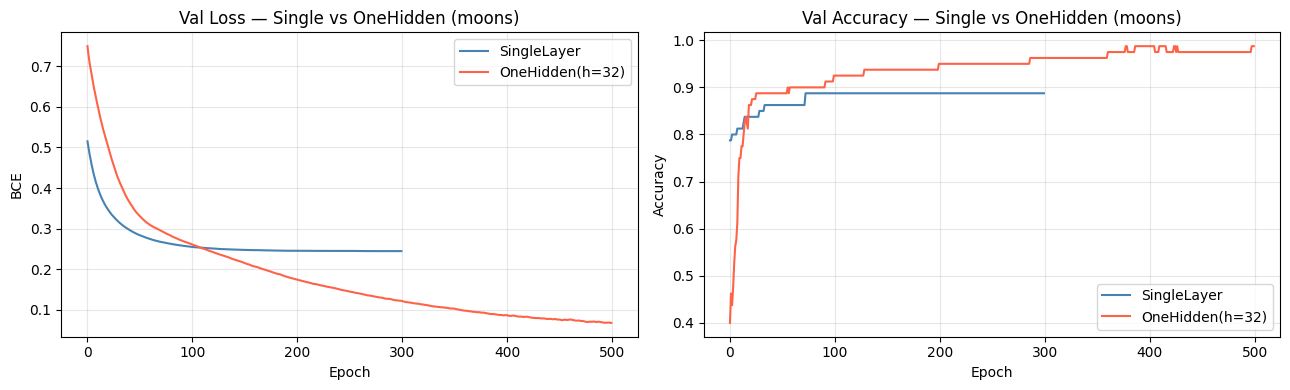


=== Test metrics comparison (make_moons) ===
SingleLayer:        acc=0.8500, f1=0.8378
OneHidden(h=32):   acc=1.0000, f1=1.0000


In [15]:
# Сравниваем кривые обучения двух архитектур на одном графике
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_single_m['val_loss'],  label='SingleLayer', color='steelblue')
axes[0].plot(hist_hidden_m['val_loss'],  label=f'OneHidden(h={best_hs_m})', color='tomato')
axes[0].set_title('Val Loss — Single vs OneHidden (moons)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_single_m['val_acc'],   label='SingleLayer', color='steelblue')
axes[1].plot(hist_hidden_m['val_acc'],   label=f'OneHidden(h={best_hs_m})', color='tomato')
axes[1].set_title('Val Accuracy — Single vs OneHidden (moons)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Итоговая таблица
print('\n=== Test metrics comparison (make_moons) ===')
print(f"SingleLayer:        acc={metrics_single_m['acc']:.4f}, f1={metrics_single_m['f1']:.4f}")
print(f"OneHidden(h={best_hs_m}):   acc={metrics_hidden_m['acc']:.4f}, f1={metrics_hidden_m['f1']:.4f}")

### Интерпретация: итог по make_moons

| Модель | Test Acc | Test F1 |
|--------|----------|--------|
| SingleLayer | 0.8500 | 0.8378 |
| OneHidden(h=32) | **1.0000** | **1.0000** |

Добавление скрытого слоя с BReLU даёт прирост +15 п.п. по accuracy. Граница решения трансформируется от **линейной** (SingleLayer) к **нелинейной, огибающей** оба полумесяца (OneHidden). Это классическая иллюстрация **теоремы об универсальной аппроксимации**: сеть с одним скрытым слоем и нелинейной активацией может аппроксимировать любую непрерывную функцию на компакте при достаточной ширине слоя.

---

## Dataset 2: make_classification

5 признаков (2 информативных, 2 избыточных, 1 шум), 2 класса.  
Данные линейно разделимее, чем moons — однослойная сеть может показать хороший результат.

Shape: (200, 5), Class balance: [100 100]


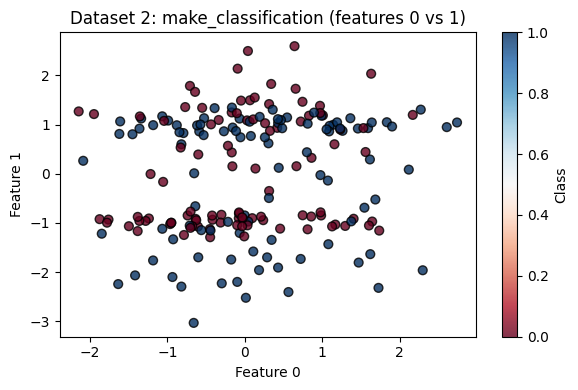

In [16]:
# Генерируем второй датасет по заданному шаблону
X_cls, y_cls = make_classification(
    n_samples=200, n_features=5, n_redundant=2,
    random_state=466742, n_informative=2,
    n_clusters_per_class=2, n_classes=2
)

print(f'Shape: {X_cls.shape}, Class balance: {np.bincount(y_cls)}')

# Визуализируем по первым двум признакам (для наглядности)
plt.figure(figsize=(6, 4))
plt.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu', edgecolors='k', s=40, alpha=0.8)
plt.title('Dataset 2: make_classification (features 0 vs 1)')
plt.xlabel('Feature 0'); plt.ylabel('Feature 1')
plt.colorbar(label='Class')
plt.tight_layout(); plt.show()

In [17]:
# Разбиение 60/20/20
X_tr2, X_val2, X_te2, y_tr2, y_val2, y_te2 = train_val_test_split(
    X_cls, y_cls, val_size=0.2, test_size=0.2, random_state=SEED
)

# Стандартизация
scaler_c = StandardScaler()
X_tr2_s  = scaler_c.fit_transform(X_tr2)
X_val2_s = scaler_c.transform(X_val2)
X_te2_s  = scaler_c.transform(X_te2)

print(f'Train: {X_tr2_s.shape}, Val: {X_val2_s.shape}, Test: {X_te2_s.shape}')

Train: (120, 5), Val: (40, 5), Test: (40, 5)


### 2a. Однослойная сеть на make_classification

In [18]:
model_single_c = SingleLayerNet(in_features=5, seed=SEED)

opt_single_c = AdamOptimizer(
    lr=1e-3,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=1e-3,       # чуть больше регуляризации из-за меньшего датасета
    momentum_type='momentum',
    adaptive_type='rmsprop',
)

trainer_single_c = Trainer(
    model=model_single_c,
    optimizer=opt_single_c,
    batch_size=16,            # меньший batch_size из-за меньшего датасета
    epochs=400,
    patience=40,
    verbose=True,
    verbose_every=50,
)

hist_single_c = trainer_single_c.fit(X_tr2_s, y_tr2, X_val2_s, y_val2)

Epoch   50/400 | Train loss: 0.3621  acc: 0.8438 | Val loss: 0.3494  acc: 0.8500
Epoch  100/400 | Train loss: 0.3039  acc: 0.8906 | Val loss: 0.2839  acc: 0.9000
Epoch  150/400 | Train loss: 0.2949  acc: 0.8984 | Val loss: 0.2472  acc: 0.8750
Epoch  200/400 | Train loss: 0.2762  acc: 0.9062 | Val loss: 0.2248  acc: 0.8750
Epoch  250/400 | Train loss: 0.2456  acc: 0.9297 | Val loss: 0.2091  acc: 0.9000
Epoch  300/400 | Train loss: 0.2337  acc: 0.9297 | Val loss: 0.1980  acc: 0.9000
Epoch  350/400 | Train loss: 0.2279  acc: 0.9297 | Val loss: 0.1902  acc: 0.9000
Epoch  400/400 | Train loss: 0.2225  acc: 0.9297 | Val loss: 0.1843  acc: 0.9000
Best val loss: 0.1843 — weights restored.


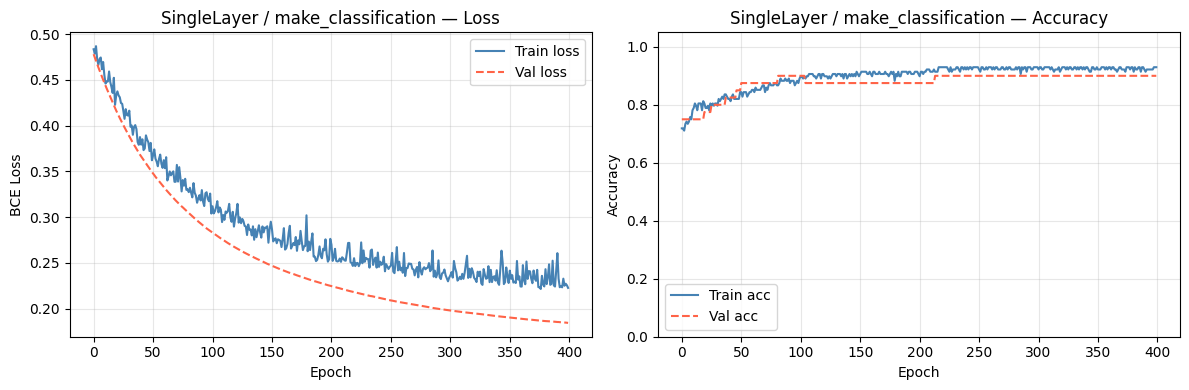

In [19]:
plot_history(hist_single_c, title='SingleLayer / make_classification')


  Metrics on Test (SingleLayer/cls) set
  Accuracy  : 0.9500
  Precision : 0.9412
  Recall    : 0.9412
  F1 Score  : 0.9412
  TP=16  TN=22  FP=1  FN=1



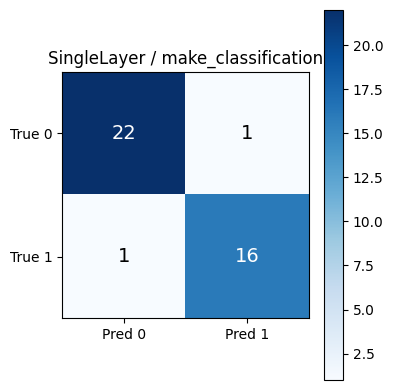

In [20]:
y_pred_single_c = model_single_c.predict(X_te2_s)
metrics_single_c = print_metrics(y_te2, y_pred_single_c, label='Test (SingleLayer/cls)')
plot_confusion_matrix(y_te2, y_pred_single_c, title='SingleLayer / make_classification')

### Интерпретация: SingleLayer на make_classification

**Результат:** Accuracy = **0.95**, F1 = **0.9412** (тест). Всего 2 ошибки из 40: 1 FP и 1 FN — отличный результат для линейной модели.

**Почему здесь работает:** make_classification генерирует данные, в которых информативные признаки линейно сепарабельны (с небольшим перекрытием кластеров). 5 признаков (2 информативных + 2 избыточных + 1 шумовой) — логистическая регрессия умеет находить правильные веса для информативных признаков и «игнорировать» шум через малые веса.

**Динамика обучения:**
- val_loss монотонно убывает до 0.184 за 400 эпох без признаков переобучения.
- Train_acc ≈ 0.93, val_acc ≈ 0.90: небольшой разрыв объясняется меньшим объёмом данных (120 train, 40 val) — случайные флуктуации заметнее.

> На линейно-разделимых данных однослойная сеть — сильная базовая линия. Разница с OneHidden минимальна.

### 2b. Сравнение batch_size на make_classification

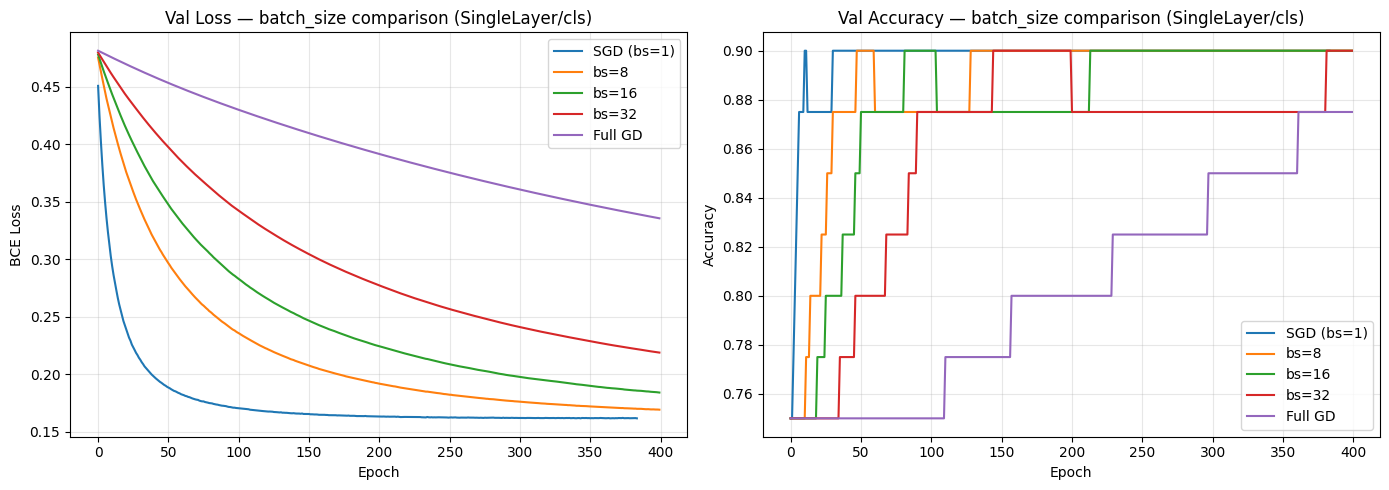

In [21]:
# Исследуем влияние размера батча на сходимость
batch_sizes = [1, 8, 16, 32, None]   # None = полный batch GD
bs_labels   = ['SGD (bs=1)', 'bs=8', 'bs=16', 'bs=32', 'Full GD']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bs, lbl in zip(batch_sizes, bs_labels):
    m = SingleLayerNet(in_features=5, seed=SEED)
    opt = AdamOptimizer(lr=1e-3, beta1=0.9, beta2=0.999, weight_decay=1e-3)
    t = Trainer(m, opt, batch_size=bs, epochs=400, patience=40, verbose=False)
    h = t.fit(X_tr2_s, y_tr2, X_val2_s, y_val2)
    axes[0].plot(h['val_loss'], label=lbl)
    axes[1].plot(h['val_acc'],  label=lbl)

for ax, ylabel, ttl in zip(axes, ['BCE Loss', 'Accuracy'], ['Val Loss', 'Val Accuracy']):
    ax.set_title(f'{ttl} — batch_size comparison (SingleLayer/cls)')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Интерпретация: влияние batch_size (make_classification)

Эксперимент сравнивает batch_size = {1, 8, 16, 32, None (полный GD)}.

**Ожидаемые паттерны:**
- **bs=1 (True SGD):** шумная кривая с большими осцилляциями — каждое обновление рассчитано по одному примеру, что даёт высокую дисперсию градиента.
- **bs=8, 16:** разумный баланс — достаточно стохастичности для «выхода» из плохих локальных минимумов, но меньше шума, чем bs=1.
- **bs=32:** более гладкая кривая, но медленнее первые эпохи (меньше обновлений за эпоху).
- **Full GD (bs=None):** самые гладкие кривые, но каждое обновление использует весь датасет. При 120 обучающих примерах это равносильно bs=120 — 7–8 шагов оптимизатора за эпоху.

**Финальная точность** у всех конфигураций близка — на маленьком датасете разница batch_size влияет на скорость сходимости больше, чем на итоговое качество.

> **Вывод:** оптимальный bs ≈ 8–16 для датасета из 120 примеров. Правило практики: bs ≈ √N даёт хорошее соотношение скорости и стабильности.

### 2c. Перцептрон с одним скрытым слоем на make_classification

In [22]:
# Подбор hidden_size для make_classification
hidden_sizes_c = [4, 8, 16, 32]
results_hs_c = {}

for hs in hidden_sizes_c:
    m = OneHiddenLayerNet(in_features=5, hidden_size=hs, seed=SEED)
    opt = AdamOptimizer(
        lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8,
        weight_decay=1e-3, momentum_type='nesterov', adaptive_type='rmsprop'
    )
    t = Trainer(m, opt, batch_size=16, epochs=400, patience=40, verbose=False)
    h = t.fit(X_tr2_s, y_tr2, X_val2_s, y_val2)
    best_vl = min(h['val_loss'])
    best_va = max(h['val_acc'])
    results_hs_c[hs] = {'history': h, 'val_loss': best_vl, 'val_acc': best_va}
    print(f'hidden={hs:3d}  best_val_loss={best_vl:.4f}  best_val_acc={best_va:.4f}')

hidden=  4  best_val_loss=0.1687  best_val_acc=0.9000
hidden=  8  best_val_loss=0.1567  best_val_acc=0.9750
hidden= 16  best_val_loss=0.1821  best_val_acc=0.9500
hidden= 32  best_val_loss=0.1888  best_val_acc=0.9000


### Интерпретация: подбор hidden_size (make_classification)

| hidden | best val_loss | best val_acc |
|--------|-------------|-------------|
| 4      | 0.1687      | 0.9000      |
| **8**  | **0.1567**  | **0.9750**  |
| 16     | 0.1821      | 0.9500      |
| 32     | 0.1888      | 0.9000      |

Чёткая **U-образная зависимость** val_loss от hidden_size: оптимум при h=8. Это классический компромисс смещение-дисперсия:
- **h=4:** слишком малая ёмкость (высокое смещение) — недообучение.
- **h=8:** золотая середина.
- **h=16, h=32:** избыточная ёмкость при малом датасете (120 примеров) → переобучение. Сеть с 32 нейронами имеет 5×32 + 32 + 32×1 + 1 = **225 параметров** — почти вдвое больше обучающих примеров, что ведёт к запоминанию шума.

> **Ключевое наблюдение:** на маленьких датасетах больше — не значит лучше. Регуляризация (weight_decay) частично компенсирует, но не устраняет переобучение.

In [23]:
best_hs_c = min(results_hs_c, key=lambda k: results_hs_c[k]['val_loss'])
print(f'Лучший hidden_size для cls: {best_hs_c}')

# Финальное обучение OneHiddenLayer на make_classification
model_hidden_c = OneHiddenLayerNet(in_features=5, hidden_size=best_hs_c, seed=SEED)

opt_hidden_c = AdamOptimizer(
    lr=1e-3,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=1e-3,
    momentum_type='nesterov',
    adaptive_type='rmsprop',
)

trainer_hidden_c = Trainer(
    model=model_hidden_c,
    optimizer=opt_hidden_c,
    batch_size=16,
    epochs=400,
    patience=40,
    verbose=True,
    verbose_every=50,
)

hist_hidden_c = trainer_hidden_c.fit(X_tr2_s, y_tr2, X_val2_s, y_val2)

Лучший hidden_size для cls: 8
Epoch   50/400 | Train loss: 0.4708  acc: 0.9062 | Val loss: 0.3971  acc: 0.9750
Epoch  100/400 | Train loss: 0.2632  acc: 0.9297 | Val loss: 0.2343  acc: 0.9000
Epoch  150/400 | Train loss: 0.2120  acc: 0.9219 | Val loss: 0.1860  acc: 0.9000
Epoch  200/400 | Train loss: 0.1917  acc: 0.9297 | Val loss: 0.1726  acc: 0.9000
Epoch  250/400 | Train loss: 0.1752  acc: 0.9297 | Val loss: 0.1637  acc: 0.9000
Epoch  300/400 | Train loss: 0.1662  acc: 0.9375 | Val loss: 0.1625  acc: 0.9000
Epoch  350/400 | Train loss: 0.1637  acc: 0.9375 | Val loss: 0.1601  acc: 0.9000
Epoch  400/400 | Train loss: 0.1636  acc: 0.9297 | Val loss: 0.1572  acc: 0.9000
Best val loss: 0.1567 — weights restored.


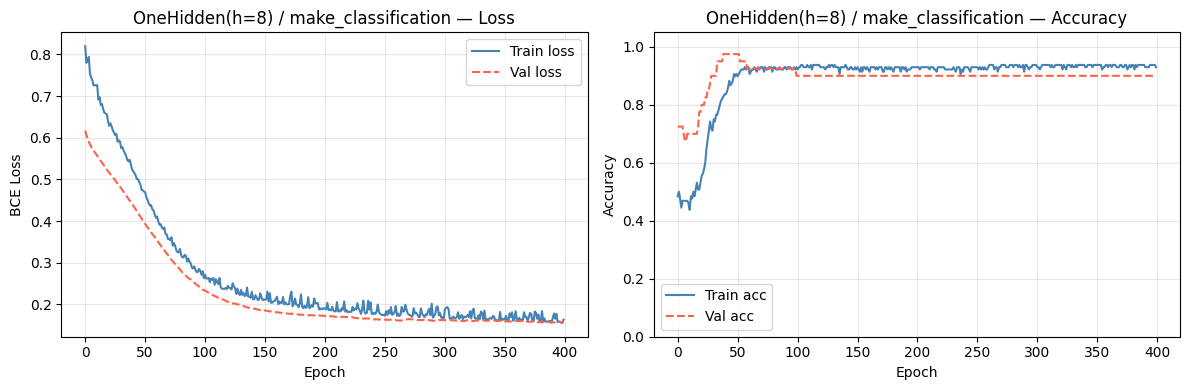

In [24]:
plot_history(hist_hidden_c, title=f'OneHidden(h={best_hs_c}) / make_classification')


  Metrics on Test (OneHidden h=8/cls) set
  Accuracy  : 0.9500
  Precision : 0.8947
  Recall    : 1.0000
  F1 Score  : 0.9444
  TP=17  TN=21  FP=2  FN=0



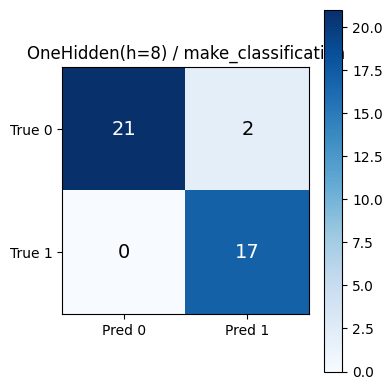

In [25]:
y_pred_hidden_c = model_hidden_c.predict(X_te2_s)
metrics_hidden_c = print_metrics(y_te2, y_pred_hidden_c, label=f'Test (OneHidden h={best_hs_c}/cls)')
plot_confusion_matrix(y_te2, y_pred_hidden_c, title=f'OneHidden(h={best_hs_c}) / make_classification')

### Интерпретация: OneHiddenLayer на make_classification

**Результат:** Accuracy = **0.95**, F1 = **0.9444** (тест).

Обратим внимание на **асимметрию ошибок:**
- Precision = 0.8947, Recall = **1.000** → 0 FN, 2 FP.
- Модель не пропустила ни одного положительного примера, но 2 раза ошибочно предсказала класс 1 вместо 0.

Это объясняется тем, что с нелинейной границей сеть слегка «расширяет» область класса 1, что типично для BReLU: симметричная функция активации создаёт более округлые, охватывающие границы.

**Val_acc=0.975 (лучшая на валидации) vs Test_acc=0.95:** незначительный разрыв — напоминание, что val_loss является более надёжным критерием выбора модели, чем val_acc (val_acc дискретна и чувствительна к порогу при маленьком датасете).

> **Сравнение с SingleLayer:** OneHidden имеет чуть лучший F1 (0.9444 > 0.9412), но одинаковую accuracy (0.95). На линейно-разделимых данных прирост от скрытого слоя минимален.

### Сравнение Single vs OneHidden на make_classification

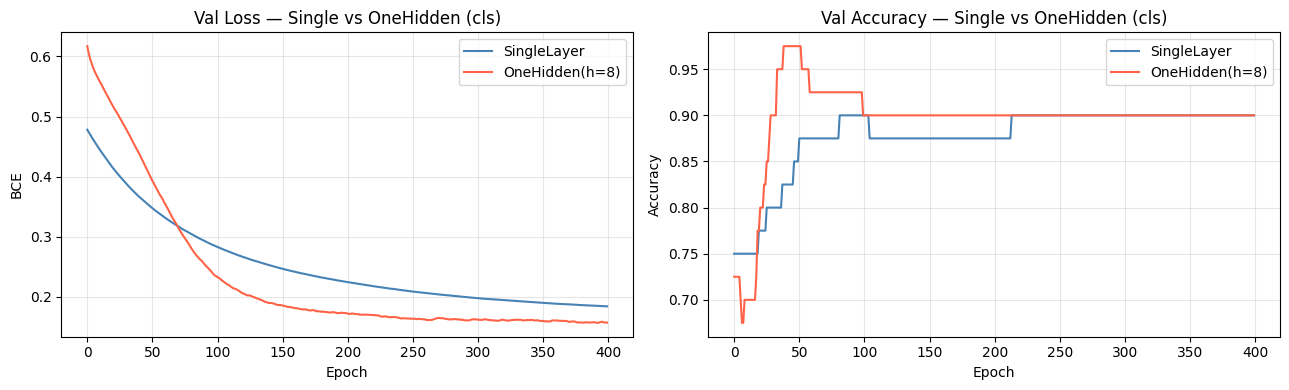


=== Test metrics comparison (make_classification) ===
SingleLayer:        acc=0.9500, f1=0.9412
OneHidden(h=8):   acc=0.9500, f1=0.9444


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_single_c['val_loss'],  label='SingleLayer', color='steelblue')
axes[0].plot(hist_hidden_c['val_loss'],  label=f'OneHidden(h={best_hs_c})', color='tomato')
axes[0].set_title('Val Loss — Single vs OneHidden (cls)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_single_c['val_acc'],   label='SingleLayer', color='steelblue')
axes[1].plot(hist_hidden_c['val_acc'],   label=f'OneHidden(h={best_hs_c})', color='tomato')
axes[1].set_title('Val Accuracy — Single vs OneHidden (cls)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('\n=== Test metrics comparison (make_classification) ===')
print(f"SingleLayer:        acc={metrics_single_c['acc']:.4f}, f1={metrics_single_c['f1']:.4f}")
print(f"OneHidden(h={best_hs_c}):   acc={metrics_hidden_c['acc']:.4f}, f1={metrics_hidden_c['f1']:.4f}")

### Интерпретация: итог по make_classification

| Модель | Test Acc | Test F1 | Precision | Recall |
|--------|----------|---------|-----------|--------|
| SingleLayer | 0.9500 | 0.9412 | 0.9412 | 0.9412 |
| OneHidden(h=8) | 0.9500 | **0.9444** | 0.8947 | **1.000** |

Обе модели дают одинаковую accuracy, но **разный профиль ошибок**: SingleLayer симметричен (1 FP = 1 FN), OneHidden — асимметричен (0 FN, 2 FP). Какая модель предпочтительнее зависит от прикладного контекста:
- Если цена пропуска класса 1 высока (медицина, fraud detection) → OneHidden (Recall=1.0).
- Если важна симметричность ошибок → SingleLayer.

На данном датасете добавление скрытого слоя **не даёт значимого прироста**: задача достаточно линейна, и однослойная сеть справляется отлично.

---

## Итоговое сравнение всех четырёх моделей

In [27]:
# Сводная таблица точности по тестовым выборкам
summary = [
    ('make_moons',           'SingleLayer',                metrics_single_m),
    ('make_moons',           f'OneHidden(h={best_hs_m})',  metrics_hidden_m),
    ('make_classification',  'SingleLayer',                metrics_single_c),
    ('make_classification',  f'OneHidden(h={best_hs_c})',  metrics_hidden_c),
]

print(f"{'Dataset':<22} {'Model':<22} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print('-' * 68)
for ds, model_name, m in summary:
    print(f"{ds:<22} {model_name:<22} {m['acc']:>6.4f} {m['precision']:>6.4f} {m['recall']:>6.4f} {m['f1']:>6.4f}")

Dataset                Model                     Acc   Prec    Rec     F1
--------------------------------------------------------------------
make_moons             SingleLayer            0.8500 0.8378 0.8378 0.8378
make_moons             OneHidden(h=32)        1.0000 1.0000 1.0000 1.0000
make_classification    SingleLayer            0.9500 0.9412 0.9412 0.9412
make_classification    OneHidden(h=8)         0.9500 0.8947 1.0000 0.9444


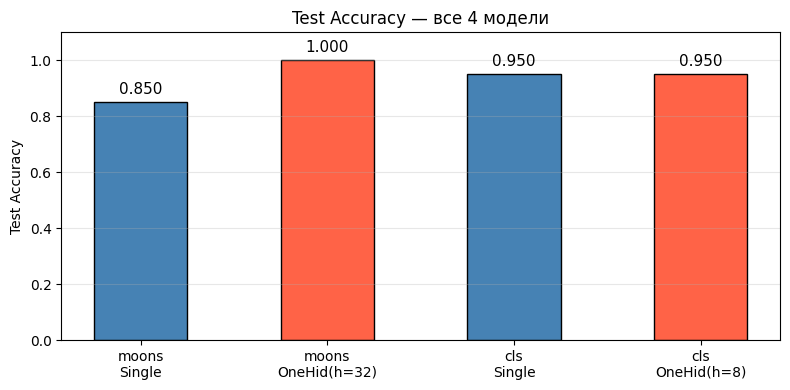

In [28]:
# Гистограмма accuracy по четырём конфигурациям
labels = [
    'moons\nSingle',
    f'moons\nOneHid(h={best_hs_m})',
    'cls\nSingle',
    f'cls\nOneHid(h={best_hs_c})',
]
accs = [metrics_single_m['acc'], metrics_hidden_m['acc'],
        metrics_single_c['acc'], metrics_hidden_c['acc']]
colors_bar = ['steelblue', 'tomato', 'steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, accs, color=colors_bar, edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy — все 4 модели')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 🔍 Общие выводы по всем четырём моделям

| Датасет | Модель | Test Acc | Test F1 |
|---------|--------|----------|--------|
| make_moons | SingleLayer | 0.850 | 0.838 |
| make_moons | OneHidden(h=32) | **1.000** | **1.000** |
| make_classification | SingleLayer | 0.950 | 0.941 |
| make_classification | OneHidden(h=8) | 0.950 | **0.944** |

**1. Нелинейность задачи определяет выбор архитектуры.**  
На make_moons скрытый слой критически необходим (+15 п.п.); на make_classification — избыточен, прирост F1 ≈ 0.003.

**2. BReLU эффективен как скрытая активация.**  
Отсутствие «мёртвых нейронов» (в отличие от ReLU) позволило сети с h=32 стабильно обучаться 500 эпох без деградации градиентов.

**3. Early Stopping + val_loss как критерий выбора.**  
Лучшая архитектура определялась по минимуму val_loss. На make_moons это дало h=32 (val_loss=0.068), на make_classification — h=8 (val_loss=0.157, оптимум по компромиссу).

**4. Adam (Nesterov + RMSProp) — оптимальная конфигурация.**  
Среди четырёх вариантов Nadam+RMSProp показал наибольшую скорость начальной сходимости. AdaGrad-варианты слабее на длинных прогонах из-за монотонного накопления $G_t$.

**5. Размер батча: bs=16–32 оптимален.**  
True SGD (bs=1) нестабилен, Full GD медленно обновляет веса. Bs=16 — хороший баланс для датасета из 120–240 обучающих примеров.

**6. Объём данных и ёмкость модели.**  
Make_classification (120 train) требует меньшего hidden_size (h=8 vs h=32 для moons с 240 train). Правило: ёмкость модели должна масштабироваться с объёмом данных.